In [1]:
import matplotlib as mpl
from scipy.optimize import minimize
%matplotlib inline
# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


from utils import *


Processing: 100%|██████████| 463/463 [00:10<00:00, 42.37it/s]


phase at the last time step: 1.60215078125


Processing: 100%|██████████| 733/733 [00:16<00:00, 43.62it/s]
 /tmp/ipykernel_23282/1005699505.py: 66WARNING:matplotlib.font_manager:findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


phase at the last time step: 0.9611375


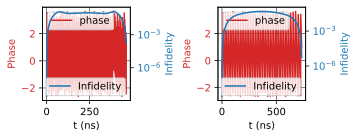

In [2]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.18_2.33.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:12<00:00, 37.81it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 700/700 [00:17<00:00, 40.19it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_70784/1819343132.py: 66

phase at the last time step: -0.42783437499999993


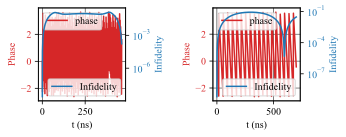

In [11]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.2_7.0585_a0.0015.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:13<00:00, 34.33it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 1500/1500 [00:44<00:00, 33.87it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_70784/4184108295.py: 66

phase at the last time step: 2.13437734375


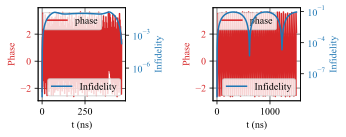

In [9]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.2_7.05855_a0.0015.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:12<00:00, 38.35it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 800/800 [00:20<00:00, 38.80it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_70784/1950434978.py: 66

phase at the last time step: 2.4407296875000006


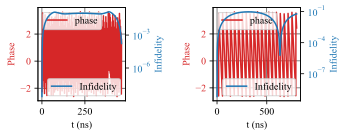

In [8]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.2_7.0586_a0.0015.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:12<00:00, 36.11it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 1500/1500 [00:41<00:00, 36.05it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_70784/1950434978.py: 66

phase at the last time step: 1.38661875


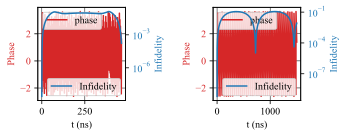

In [6]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.2_7.0586_a0.0015.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:12<00:00, 37.23it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 1300/1300 [00:33<00:00, 39.32it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_70784/3552058942.py: 66

phase at the last time step: 2.12363515625


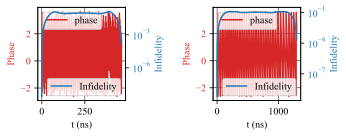

In [4]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.14_7.0587.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:11<00:00, 38.75it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 1200/1200 [00:30<00:00, 39.81it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_70784/273207798.py: 66

phase at the last time step: 2.5496164062500006


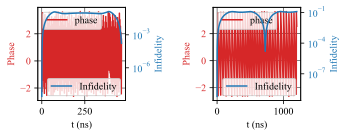

In [2]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.2_7.0588.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:11<00:00, 40.16it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 1200/1200 [00:29<00:00, 41.09it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_70248/47689420.py: 66

phase at the last time step: -0.2198265625


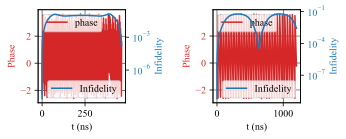

In [2]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.2_7.0586.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:11<00:00, 39.70it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 1300/1300 [00:32<00:00, 39.44it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_69759/781323199.py: 66

phase at the last time step: 1.4015671875


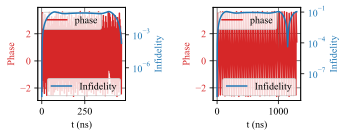

In [3]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.15_7.0587.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:11<00:00, 40.09it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 900/900 [00:22<00:00, 40.79it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_69467/2350884168.py: 66

phase at the last time step: -1.6862234375


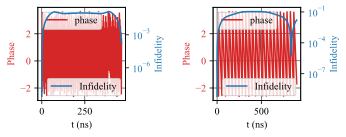

In [2]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.17_7.0586.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:11<00:00, 39.46it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 1200/1200 [00:29<00:00, 40.26it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_68663/1479478517.py: 66

phase at the last time step: -0.64198984375


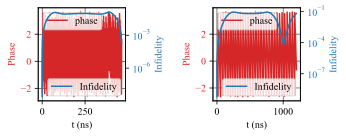

In [4]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.17.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:11<00:00, 41.89it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 800/800 [00:19<00:00, 41.82it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_68663/4104571771.py: 66

phase at the last time step: 1.9247046875


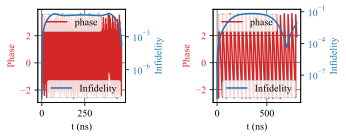

In [2]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states_g0.2.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:11<00:00, 41.25it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 418/418 [00:10<00:00, 41.02it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_68663/811166634.py: 66

phase at the last time step: 1.279196875


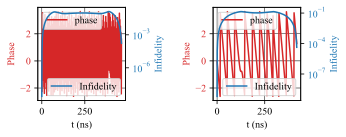

In [3]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            'pickles/sesolve_threeoutcome_reference_states.pkl',
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])

        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()